# DeBERTa Results Comparison

Compare metrics across DeBERTa runs (zero-shot, few-shot, LoRA) from timestamped folders in `results/`.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
SAVE_FIGURES = True

RUN_TYPES = {
    "zero_shot": ("deberta_zero_shot_metrics.json", "deberta_zero_shot_test_metrics.json"),
    "few_shot": ("deberta_few_shot_metrics.json", "deberta_few_shot_test_metrics.json"),
    "lora": ("deberta_lora_metrics.json", "deberta_lora_test_metrics.json"),
}
MODEL_LABELS = {"zero_shot": "Zero-shot", "few_shot": "Few-shot", "lora": "LoRA"}

In [ ]:
def get_run_dirs():
    if not RESULTS_DIR.exists():
        return []
    return sorted([d for d in RESULTS_DIR.iterdir() if d.is_dir()], reverse=True)


def latest_run_dir_for(run_type: str):
    train_name, _ = RUN_TYPES[run_type]
    return next((d for d in get_run_dirs() if (d / train_name).exists()), None)


def load_metrics(run_dir: Path, run_type: str) -> dict:
    train_name, test_name = RUN_TYPES[run_type]
    out = {}
    for path, key in [(run_dir / train_name, "train"), (run_dir / test_name, "test")]:
        out[key] = json.loads(path.read_text()) if path.exists() else None
    return out


def load_outputs(run_dir: Path, run_type: str, split: str) -> list | None:
    if split == "train":
        name = RUN_TYPES[run_type][0].replace("_metrics.json", "_outputs.json")
    else:
        name = RUN_TYPES[run_type][1].replace("_metrics.json", "_outputs.json")
    path = run_dir / name
    return json.loads(path.read_text()) if path.exists() else None

In [ ]:
latest = {rt: latest_run_dir_for(rt) for rt in RUN_TYPES}
data = {}
outputs = {}
for run_type, run_dir in latest.items():
    if run_dir is None:
        data[run_type] = {"train": None, "test": None}
        outputs[run_type] = {"train": None, "test": None}
        continue
    data[run_type] = load_metrics(run_dir, run_type)
    outputs[run_type] = {
        "train": load_outputs(run_dir, run_type, "train"),
        "test": load_outputs(run_dir, run_type, "test"),
    }

## Aggregate metrics comparison

Bar charts of zero-one accuracy, mean min swaps, and (when available) mean inference time by model and split.

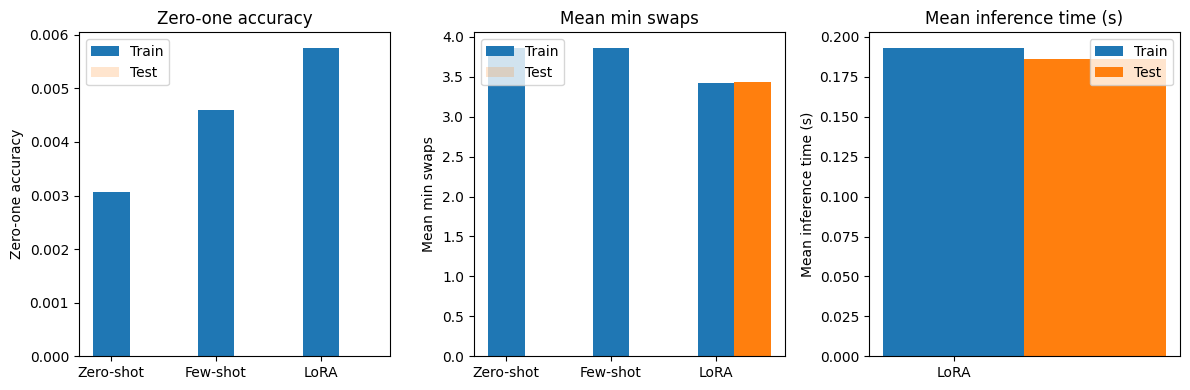

In [ ]:
def _collect_metric(data, metric_key):
    rows = []
    for run_type in RUN_TYPES:
        for split in ("train", "test"):
            m = data[run_type].get(split)
            if m is None or metric_key not in m:
                continue
            rows.append({
                "model": MODEL_LABELS[run_type],
                "split": split.capitalize(),
                "value": m[metric_key],
            })
    return rows


def _draw_metric_bars(ax, data, metric_key, ylabel):
    rows = _collect_metric(data, metric_key)
    if not rows:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        return
    models = list(dict.fromkeys(r["model"] for r in rows))
    x = np.arange(len(models))
    w = 0.35
    for i, split in enumerate(["Train", "Test"]):
        vals = [next((r["value"] for r in rows if r["model"] == m and r["split"] == split), None) for m in models]
        mask = [v is not None for v in vals]
        vals_plot = [v if v is not None else 0 for v in vals]
        off = -w / 2 + w * i + w / 2
        bars = ax.bar(x + off, vals_plot, w, label=split)
        for j, (v, m) in enumerate(zip(vals, mask)):
            if not m:
                bars[j].set_alpha(0.2)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_title(ylabel)


panels = [
    ("zero_one_accuracy", "Zero-one accuracy"),
    ("mean_min_swaps", "Mean min swaps"),
]
if any(
    data[rt].get(s) and data[rt].get(s).get("mean_inference_time_sec") is not None
    for rt in RUN_TYPES for s in ("train", "test")
):
    panels.append(("mean_inference_time_sec", "Mean inference time (s)"))
n_axes = len(panels)
fig, axes = plt.subplots(1, n_axes, figsize=(4 * n_axes, 4))
if n_axes == 1:
    axes = [axes]
for ax, (key, label) in zip(axes, panels):
    _draw_metric_bars(ax, data, key, label)
plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "eval_aggregate_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
## Per-model distributions

Distributions of min swaps and correct groups per puzzle for each model (from latest run outputs).

SyntaxError: invalid syntax (299499910.py, line 3)

### Min swaps distribution (train split)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, 6) - 0.5
for run_type in RUN_TYPES:
    out = outputs[run_type].get("train")
    if not out:
        continue
    swaps = [r.get("min_swaps", 4) for r in out]
    ax.hist(swaps, bins=bins, alpha=0.6, label=MODEL_LABELS[run_type], density=True, edgecolor="black")
ax.set_xlabel("Min swaps to correct")
ax.set_ylabel("Density")
ax.set_xticks([0, 1, 2, 3, 4])
ax.legend()
ax.set_title("Min swaps distribution by model (train)")
plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "eval_min_swaps_hist.png", dpi=150, bbox_inches="tight")
plt.show()

,run_type,split,zero_one_accuracy,mean_min_swaps,mean_n_correct_groups,mean_inference_time_sec,n_eval
0,zero_shot,train,0.003067,3.861963,NaN,NaN,652
1,few_shot,train,0.004601,3.861963,NaN,NaN,652
2,lora,train,0.005758,3.418426,0.366603,0.19326,521
3,lora,test,0.000000,3.435115,0.374046,0.18602,131


### Correct groups per puzzle (train split)

In [ ]:
bins_cg = np.arange(0, 6) - 0.5
fig, ax = plt.subplots(figsize=(8, 4))
for run_type in RUN_TYPES:
    out = outputs[run_type].get("train")
    if not out:
        continue
    cg = [r.get("n_correct_groups", 0) for r in out]
    ax.hist(cg, bins=bins_cg, alpha=0.6, label=MODEL_LABELS[run_type], density=True, edgecolor="black")
ax.set_xlabel("Correct groups per puzzle")
ax.set_ylabel("Density")
ax.set_xticks([0, 1, 2, 3, 4])
ax.legend()
ax.set_title("Correct groups distribution by model (train)")
plt.tight_layout()
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "eval_correct_groups_hist.png", dpi=150, bbox_inches="tight")
plt.show()

Compare zero_shot vs few_shot (train, n=652):
  few_shot better: 155  same: 335  zero_shot better: 162
  zero_shot zero_one=0.0031  mean_min_swaps=3.86
  few_shot zero_one=0.0046  mean_min_swaps=3.86
Missing outputs for test.
Compare zero_shot vs lora (train, n=521):
  lora better: 247  same: 154  zero_shot better: 120
  zero_shot zero_one=0.0031  mean_min_swaps=3.86
  lora zero_one=0.0058  mean_min_swaps=3.42
Missing outputs for test.


### Min swaps by model (box plot)

/var/folders/w3/5cjnw3xn1jg8w2z_kphmf1840000gn/T/ipykernel_23359/3028663052.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


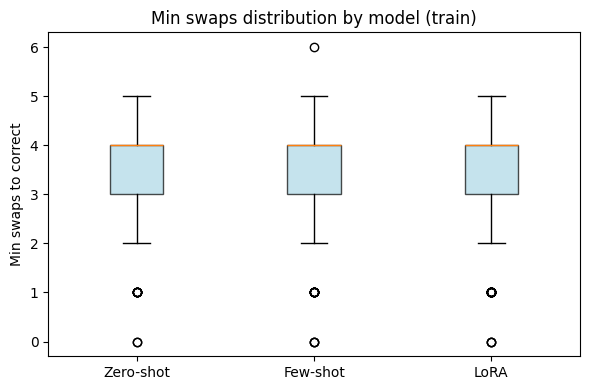

In [ ]:
box_data = []
box_labels = []
for run_type in RUN_TYPES:
    out = outputs[run_type].get("train")
    if not out:
        continue
    swaps = [r.get("min_swaps", 4) for r in out]
    box_data.append(swaps)
    box_labels.append(MODEL_LABELS[run_type])
if box_data:
    fig, ax = plt.subplots(figsize=(6, 4))
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
        patch.set_alpha(0.7)
    ax.set_ylabel("Min swaps to correct")
    ax.set_title("Min swaps distribution by model (train)")
    plt.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / "eval_min_swaps_box.png", dpi=150, bbox_inches="tight")
    plt.show()

## Pairwise comparison (train split)

For each pair of models, count how many puzzles the second model solves better, same, or worse than the first (by zero_one then min_swaps). Only includes puzzles present in both runs.

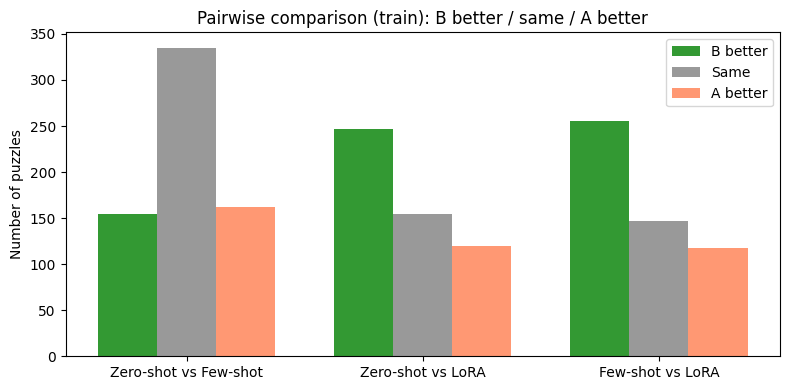

In [29]:
def pairwise_counts(type_a: str, type_b: str, split: str = "train"):
    dir_a, dir_b = latest_run_dir_for(type_a), latest_run_dir_for(type_b)
    if dir_a is None or dir_b is None:
        return None
    out_a = load_outputs(dir_a, type_a, split)
    out_b = load_outputs(dir_b, type_b, split)
    if not out_a or not out_b:
        return None
    by_idx = {r["index"]: {"a": r} for r in out_a}
    for r in out_b:
        by_idx.setdefault(r["index"], {})["b"] = r
    better = same = worse = 0
    for rec in by_idx.values():
        if "a" not in rec or "b" not in rec:
            continue
        za, zb = rec["a"].get("zero_one", 0), rec["b"].get("zero_one", 0)
        sa, sb = rec["a"].get("min_swaps", 4), rec["b"].get("min_swaps", 4)
        if zb > za or (zb == za and sb < sa):
            better += 1
        elif zb == za and sb == sa:
            same += 1
        else:
            worse += 1
    return {"better": better, "same": same, "worse": worse}


pairs = [("zero_shot", "few_shot"), ("zero_shot", "lora"), ("few_shot", "lora")]
results = []
for a, b in pairs:
    c = pairwise_counts(a, b, "train")
    if c:
        results.append((f"{MODEL_LABELS[a]} vs {MODEL_LABELS[b]}", c))

if results:
    fig, ax = plt.subplots(figsize=(8, 4))
    labels = [r[0] for r in results]
    better = [r[1]["better"] for r in results]
    same = [r[1]["same"] for r in results]
    worse = [r[1]["worse"] for r in results]
    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w, better, w, label="B better", color="green", alpha=0.8)
    ax.bar(x, same, w, label="Same", color="gray", alpha=0.8)
    ax.bar(x + w, worse, w, label="A better", color="coral", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Number of puzzles")
    ax.legend()
    ax.set_title("Pairwise comparison (train): B better / same / A better")
    plt.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / "eval_pairwise.png", dpi=150, bbox_inches="tight")
    plt.show()

### Test split: min swaps and correct groups (when available)

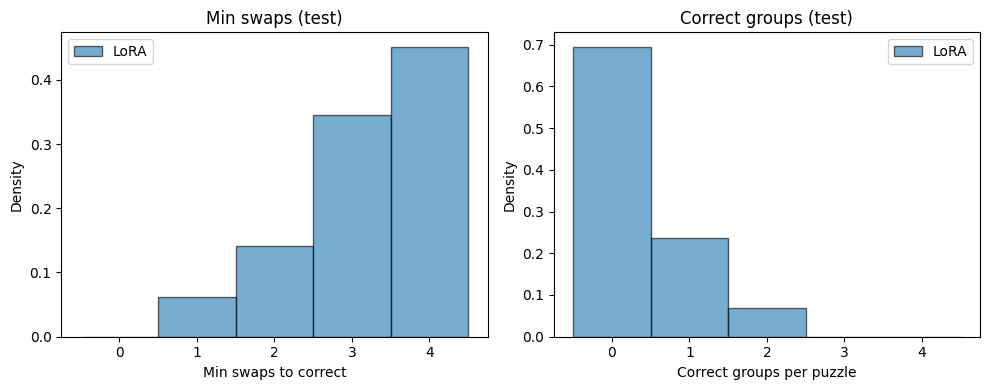

In [30]:
test_available = any(outputs[rt].get("test") for rt in RUN_TYPES)
if test_available:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    bins = np.arange(0, 6) - 0.5
    for ax, key, xlabel, title in [
        (axes[0], "min_swaps", "Min swaps to correct", "Min swaps (test)"),
        (axes[1], "n_correct_groups", "Correct groups per puzzle", "Correct groups (test)"),
    ]:
        for run_type in RUN_TYPES:
            out = outputs[run_type].get("test")
            if not out:
                continue
            vals = [r.get(key, 4 if key == "min_swaps" else 0) for r in out]
            ax.hist(vals, bins=bins, alpha=0.6, label=MODEL_LABELS[run_type], density=True, edgecolor="black")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.legend()
        ax.set_title(title)
    plt.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / "eval_test_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()